In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

from utils import config_ml
from src.core.model import pack_all_data_for_ml_models, sliding_windows_cross_validating

from utils.utils import connection

In [2]:
conn = connection()

In [3]:
def parse_model_string(s):
    class_match = re.match(r'([A-Za-z0-9_]+)\(', s)
    class_name = class_match.group(1) if class_match else None
    
    pattern = r'(\w+)=([^,)]+(?:,[^,)]+)*?)(?=\s*[,)])'
    params = {}
    for match in re.finditer(pattern, s):
        key = match.group(1)
        value_str = match.group(2).strip()
        if value_str == 'None':
            value = None
        elif value_str.isdigit():
            value = int(value_str)
        elif value_str.replace('.', '', 1).isdigit():
            value = float(value_str)
        elif value_str in ('True', 'False'):
            value = value_str == 'True'
        elif value_str.startswith("'") and value_str.endswith("'"):
            value = value_str[1:-1]
        else:
            value = value_str
            
        if value in [None, 'nan', False, '-1']:
            continue
        
        params[key] = value
    return {'class': class_name, 'params': params}

In [4]:
companies = pd.read_sql("SELECT * FROM companies", connection())
tickers = companies['ticker']
left_date = ['2025-07-01', '2026-01-12', '2026-01-31']
right_date = ['2025-09-01', '2026-03-12', '2026-03-31']
train_period = config_ml.TRAIN_PERIOD
val_period = config_ml.VAL_PERIOD
test_period = config_ml.TEST_PERIOD
step = config_ml.STEP
models = config_ml.MODELS
n_trials = config_ml.N_TRIALS
metric_optuna = config_ml.METRIC_OPTUNA
top_n_features = config_ml.TOP_N_FEATURES

In [5]:
try:
    df_ml_db_all = pd.read_sql(
        "SELECT * FROM ml_models_data",
        conn,
    )
    
except Exception:
    pass

                  mean  median       std
model_name                              
XGBoost       0.052123  0.0375  0.040272
RandomForest  0.053753  0.0435  0.039703
CatBoost      0.056000  0.0460  0.041379
DecisionTree  0.060233  0.0480  0.041794
LightGBM      0.063534  0.0510  0.044460


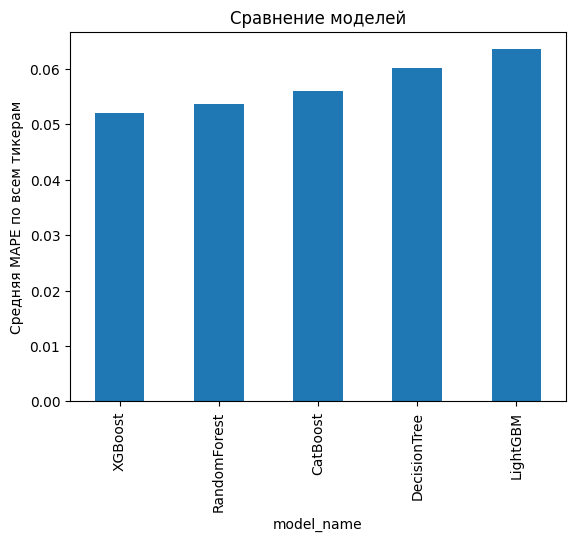

In [6]:
avg_mape = df_ml_db_all.groupby('model_name')['mape_mean'].agg(['mean', 'median', 'std']).sort_values('mean')
print(avg_mape)

avg_mape['mean'].plot(kind='bar')
plt.ylabel('Средняя MAPE по всем тикерам')
plt.title('Сравнение моделей')
plt.show()

                   mean  median         std
model_name                                 
XGBoost       78.239699  4.8910  481.551491
RandomForest  83.075568  5.1220  506.112089
CatBoost      83.580247  5.2050  501.417178
DecisionTree  92.390384  6.2335  567.771160
LightGBM      95.422788  6.8425  573.972348


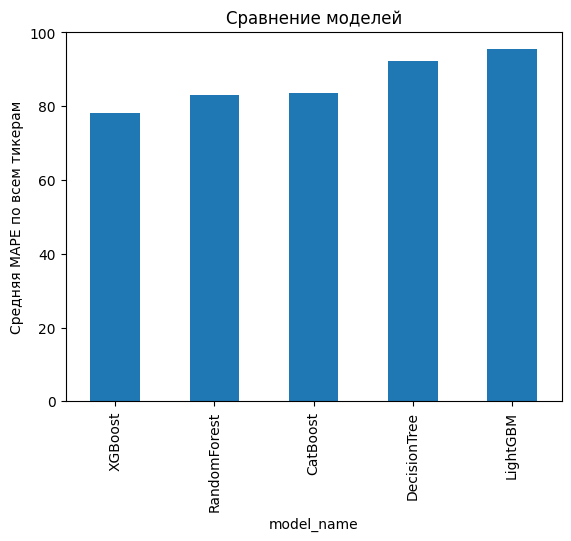

In [23]:
avg_mae = df_ml_db_all.groupby('model_name')['mae_mean'].agg(['mean', 'median', 'std']).sort_values('mean')
print(avg_mae)

avg_mae['mean'].plot(kind='bar')
plt.ylabel('Средняя MAPE по всем тикерам')
plt.title('Сравнение моделей')
plt.show()

In [7]:
try:
    df_ml_db = pd.read_sql(
        "SELECT ticker, model_name, mape_mean, mae_mean, model_value, best_features FROM ml_models_data WHERE model_name = 'XGBoost' ORDER BY mape_mean",
        conn,
    )
    
    display(df_ml_db)
except Exception:
    pass

,ticker,model_name,mape_mean,mae_mean,model_value,best_features
0,RENI,XGBoost,0.003,0.311,"XGBRegressor(base_score=None, booster=None, ca...","[""RUGOLD_open_rm_6"", ""BPSIG_open_lag_15"", ""low..."
1,NMTP,XGBoost,0.004,0.033,"XGBRegressor(base_score=None, booster=None, ca...","[""RUGOLD_open_rm_6"", ""high_lag_9_low_lag_9_dif..."
2,BSPB,XGBoost,0.005,1.596,"XGBRegressor(base_score=None, booster=None, ca...","[""RUSFAR1MRT_open_lag_15"", ""RUSFAR_open_lag_14..."
3,AQUA,XGBoost,0.006,3.030,"XGBRegressor(base_score=None, booster=None, ca...","[""RUGOLD_open_rm_6"", ""high_lag_21_low_lag_21_d..."
4,X5,XGBoost,0.007,16.209,"XGBRegressor(base_score=None, booster=None, ca...","[""RUSFAR1MRT_open_lag_15"", ""RUSFAR_open_lag_14..."
...,...,...,...,...,...,...
141,MVID,XGBoost,0.157,10.195,"XGBRegressor(base_score=None, booster=None, ca...","[""RUSFAR_open_lag_14"", ""RUMBTRNS_open_lag_2"", ..."
142,SFIN,XGBoost,0.160,137.917,"XGBRegressor(base_score=None, booster=None, ca...","[""RUGOLD_open_rm_6"", ""RUABITR_open_rm_17"", ""tf..."
143,VSMO,XGBoost,0.167,5737.236,"XGBRegressor(base_score=None, booster=None, ca...","[""RUCBTRNS_open_lag_15"", ""RUGOLD_open_lag_3"", ..."
144,MAGN,XGBoost,0.176,4.593,"XGBRegressor(base_score=None, booster=None, ca...","[""RUPCI_open_lag_20"", ""RUSFAR1MRT_open_lag_15""..."


In [8]:
for idx, row in df_ml_db.iterrows():
    parsed = parse_model_string(row['model_value'])
    print(parsed)

{'class': 'XGBRegressor', 'params': {'colsample_bytree': 0.7133422283409027, 'learning_rate': 0.06205653164661692, 'max_depth': 3, 'n_estimators': 264}}
{'class': 'XGBRegressor', 'params': {'colsample_bytree': 0.7708488875028818, 'learning_rate': 0.044706884059623454, 'max_depth': 10, 'n_estimators': 252}}
{'class': 'XGBRegressor', 'params': {'colsample_bytree': 0.8623333446775904, 'learning_rate': 0.022243112742679608, 'max_depth': 8, 'n_estimators': 165}}
{'class': 'XGBRegressor', 'params': {'colsample_bytree': 0.7841476827526374, 'learning_rate': 0.012968181969758259, 'max_depth': 5, 'n_estimators': 148}}
{'class': 'XGBRegressor', 'params': {'colsample_bytree': 0.7387928885803693, 'learning_rate': 0.26701276431896476, 'max_depth': 3, 'n_estimators': 269}}
{'class': 'XGBRegressor', 'params': {'colsample_bytree': 0.9799098397864213, 'learning_rate': 0.17077711883928628, 'max_depth': 4, 'n_estimators': 132}}
{'class': 'XGBRegressor', 'params': {'colsample_bytree': 0.9242225145501788, '

In [9]:
try:
    df_ml_db = pd.read_sql(
        "SELECT model_name, mape_mean, mae_mean, model_value, best_features FROM ml_models_data ORDER BY mape_mean",
        conn,
    )

    df_ml_best = (
        df_ml_db.sort_values("mape_mean")
        .groupby("model_name", as_index=False)
        .first()
        .sort_values("mape_mean")
    ).head(1)

    display(df_ml_best)
except Exception:
    pass

,model_name,mape_mean,mae_mean,model_value,best_features
4,XGBoost,0.003,0.311,"XGBRegressor(base_score=None, booster=None, ca...","[""RUGOLD_open_rm_6"", ""BPSIG_open_lag_15"", ""low..."


In [10]:
for idx, row in df_ml_best.iterrows():
    parsed = parse_model_string(row['model_value'])
    print(parsed)

{'class': 'XGBRegressor', 'params': {'colsample_bytree': 0.7133422283409027, 'learning_rate': 0.06205653164661692, 'max_depth': 3, 'n_estimators': 264}}


In [11]:
xgboost_fixed_params_all_tickers = pd.read_csv('xgboost_fixed_params_all_tickers.csv')

In [ ]:
FIXED_XGB_PARAMS = parsed.get("params", {})


def train_xgboost_fixed_params(_, windows, ticker, top_n_features=20):
    df_ml = pd.DataFrame(columns=["test_period", "model_name", "mape", "mae"])
    mape_list = []
    mae_list = []

    for idx, window in enumerate(windows):
        train, val, test = window["train"], window["val"], window["test"]
        exclude = [
            "dt",
            "ticker",
            "ticker_x",
            "ticker_y",
            "target",
        ]
        numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
        feature_cols = [c for c in numeric_cols if c not in exclude]

        print(
            f"Тикер {ticker}, окно {idx + 1}/{len(windows)}: обучение {len(train)} дн., тест {len(test)} дн."
        )

        train = train.fillna(0)
        val = val.fillna(0)
        test = test.fillna(0)

        X_train, y_train = train[feature_cols], train["target"]
        # X_val, y_val = val[feature_cols], val["target"]
        X_test, y_test = test[feature_cols], test["target"]

        temp_model = XGBRegressor(**FIXED_XGB_PARAMS)
        temp_model.fit(X_train, y_train)

        if hasattr(temp_model, "feature_importances_"):
            importances = temp_model.feature_importances_
            feature_imp = list(zip(feature_cols, importances))
            feature_imp.sort(key=lambda x: x[1], reverse=True)
            selected_features = [f for f, imp in feature_imp[:top_n_features]]
        else:
            selected_features = feature_cols[:top_n_features]

        final_model = XGBRegressor(**FIXED_XGB_PARAMS)
        final_model.fit(X_train[selected_features], y_train)

        y_pred = final_model.predict(X_test[selected_features])
        test_mape = mean_absolute_percentage_error(y_test, y_pred)
        test_mae = mean_absolute_error(y_test, y_pred)

        mape_list.append(test_mape)
        mae_list.append(test_mae)

        new_row = pd.Series(
            [
                f"{window['dates']['test'][0]} - {window['dates']['test'][1]}",
                "XGBoost_fixed",
                round(test_mape, 5),
                round(test_mae, 3),
            ],
            index=df_ml.columns,
        )
        df_ml = pd.concat([df_ml, new_row.to_frame().T], ignore_index=True)

        print(f"  → MAPE = {test_mape:.5f}, MAE = {test_mae:.3f}")

    mean_mape = np.mean(mape_list)
    mean_mae = np.mean(mae_list)
    print(
        f"\nТикер {ticker}: средняя MAPE = {mean_mape:.5f}, средняя MAE = {mean_mae:.3f}\n"
    )

    return df_ml, mean_mape, mean_mae


if xgboost_fixed_params_all_tickers.empty:
    all_results = []

    for ticker in tickers:
        try:
            print(f"\n{'=' * 60}\nОбработка тикера: {ticker}\n{'=' * 60}")

            for l, r in zip(left_date, right_date):
                data = pack_all_data_for_ml_models(ticker, l, r, connection())
                df = data.copy()
                df = df[~df["target"].isnull()].sort_values("dt")

                windows = sliding_windows_cross_validating(
                    df, train_period, val_period, test_period, step
                )

                df_ml, mean_mape, mean_mae = train_xgboost_fixed_params(
                    df, windows, ticker
                )

                all_results.append(
                    {
                        "ticker": ticker,
                        "mean_MAPE": mean_mape,
                        "mean_MAE": mean_mae,
                        "left_date": l,
                        "right_date": r,
                    }
                )

        except Exception as e:
            print(f"Ошибка при обработке тикера {ticker}: {e}")
            continue

    results_df = pd.DataFrame(all_results)
    print("\n" + "=" * 60)
    print("ИТОГОВЫЕ МЕТРИКИ ПО ВСЕМ ТИКЕРАМ (XGBoost, фиксированные параметры)")
    print("=" * 60)
    print(results_df[["ticker", "mean_MAPE", "mean_MAE"]].to_string(index=False))

    avg_mape_all = results_df["mean_MAPE"].mean()
    avg_mae_all = results_df["mean_MAE"].mean()
    print(f"\nСредняя MAPE по всем тикерам: {avg_mape_all:.5f}")
    print(f"Средняя MAE по всем тикерам:  {avg_mae_all:.3f}")

    results_df.to_csv("xgboost_fixed_params_all_tickers.csv", index=False)

In [14]:
xgboost_fixed_params_all_tickers[['ticker', 'mean_MAPE', 'mean_MAE']]

,ticker,mean_MAPE,mean_MAE
0,SBER,0.010455,3.281427
1,SBER,0.027149,8.550255
2,SBER,0.011277,3.590414
3,SBERP,0.012861,4.009954
4,SBERP,0.029981,9.440101
...,...,...,...
187,VSMO,NaN,NaN
188,VSMO,NaN,NaN
189,IRKT,0.028038,0.809206
190,IRKT,NaN,NaN


In [15]:
result = xgboost_fixed_params_all_tickers.loc[
    xgboost_fixed_params_all_tickers['mean_MAPE'].notna(),
    ['ticker', 'mean_MAPE', 'mean_MAE']
].reset_index().drop(columns=['index'])
result

,ticker,mean_MAPE,mean_MAE
0,SBER,0.010455,3.281427
1,SBER,0.027149,8.550255
2,SBER,0.011277,3.590414
3,SBERP,0.012861,4.009954
4,SBERP,0.029981,9.440101
...,...,...,...
138,SELG,0.015135,0.879627
139,SELG,0.066001,3.416886
140,LEAS,0.018116,11.410406
141,VSMO,0.155105,5328.622768


In [41]:
df_ml_best['mape_mean']

4    0.003
Name: mape_mean, dtype: float64

In [43]:
# прогноз 
result['mean_MAPE'].mean()

np.float64(0.05037618096722879)

In [44]:
# факт из ml_models_data
avg_mape.loc['XGBoost', 'mean']

np.float64(0.05212328767123288)

In [45]:
FIXED_XGB_PARAMS

{'colsample_bytree': 0.7133422283409027,
 'learning_rate': 0.06205653164661692,
 'max_depth': 3,
 'n_estimators': 264}

__модель - XGBoost__

```python
params = {
    'colsample_bytree': 0.7133422283409027,
    'learning_rate': 0.06205653164661692,
    'max_depth': 3,
    'n_estimators': 264
}
```